# P2P Cops & Robbers — Agent-vs-Agent Analysis (D7)

**Group:** nis-yar1
**Authors:** Nissim Deri, Yarden Tziar
**Course:** Orchestration of AI Agents (Dr. Segal)
**Date:** 2026-07-14

This notebook presents the mandatory D7 evidence artifact. All results are produced by
the in-process lab runner (`pursuit.sdk.lab_gate.run_lab_versus`) against the **signed**
`game.json` parameters - no hardcoded constants, real recursive-Bayes **BeliefV2**.

> **Honesty note.** An earlier version of this notebook showed a *self-play* table in
> which the thief won 100% of every matchup. That was **misleading**: on the signed board
> the thief starts at the centre (3,3) and the cop at the corner (0,0) - a 6-cell BFS
> handicap that *any* thief survives regardless of brain quality. This version replaces it
> with a real **agent-vs-agent** experiment (roles swapped each seed) that cancels the
> positional handicap by symmetry and therefore isolates **strategy quality**.

Sections:
1. Setup - imports and data loading
2. Agent-vs-Agent Results - our BeliefV2 brains vs the greedy baseline (+ mirror control)
3. Belief Convergence - BeliefV2 Shannon entropy over turns
4. Strategy Comparison - structured attribute table
5. Conclusions

---
## 1. Setup

In [1]:
import json
import math
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Resolve repo root from notebook location
REPO = Path('..').resolve()
LAB_DIR = REPO / 'artifacts' / 'lab'

print(f'Repo root : {REPO}')
print(f'Lab dir   : {LAB_DIR}')
print(f'Python    : {sys.version.split()[0]}')

Repo root : C:\Users\nderi\OneDrive - NVIDIA Corporation\Desktop\לימודים\AI Agents orchestration\final_project
Lab dir   : C:\Users\nderi\OneDrive - NVIDIA Corporation\Desktop\לימודים\AI Agents orchestration\final_project\artifacts\lab
Python    : 3.12.13


In [2]:
# Load lab results
with open(LAB_DIR / 'first_blood.json', encoding='utf-8') as fh:
    LAB = json.load(fh)

with open(LAB_DIR / 'entropy_traces.json', encoding='utf-8') as fh:
    ENTROPY = json.load(fh)

BOARD = LAB['board']
print('Experiment          :', LAB['experiment'])
print('Board size          :', BOARD['grid_size'], 'x', BOARD['grid_size'])
print('Cop start           :', BOARD['cop_start'], '(corner)')
print('Thief start         :', BOARD['thief_start'], '(centre)')
print('Initial BFS gap     :', BOARD['initial_bfs_gap'], 'cells')
print('Survival threshold  :', BOARD['survival_threshold'], 'thief moves')
print('Matchups loaded     :', list(LAB['matchups'].keys()))
print('Entropy traces      :', ENTROPY['n_games'], 'games')

Experiment          : P2P Cops & Robbers — Agent-vs-Agent Lab (D7, BeliefV2)
Board size          : 7 x 7
Cop start           : [0, 0] (corner)
Thief start         : [3, 3] (centre)
Initial BFS gap     : 6 cells
Survival threshold  : 35 thief moves
Matchups loaded     : ['interceptor_vs_greedy', 'ours_vs_ours_mirror']
Entropy traces      : 5 games


---
## 2. Agent-vs-Agent Results

Two matchups, **100 seeds each played twice with roles swapped** (200 sub-games), base
seed 42. Both sides use the real domain rules, signed parameters and the real BeliefV2
filter; no sockets/LLMs.

`run_lab_versus` swaps which agent plays cop/thief on each identical seed, so
**`win_rate_A` measures agent A's brains vs agent B's** with the cop-start handicap
cancelled by symmetry. `p_value_A` is a sign test that A differs from B.

- **interceptor_vs_greedy** - our BeliefV2 brains (A) vs the reference greedy baseline (B).
- **ours_vs_ours_mirror** - our brain-set vs an identical copy (control; must be ~50%).

In [3]:
# Build summary table (agent-vs-agent schema)
rows = []
labels_short = []
for key, m in LAB['matchups'].items():
    rows.append({
        'Matchup': key,
        'Agent A': m['agent_a'],
        'Agent B': m['agent_b'],
        'Games': m['games'],
        'win_rate_A': m['win_rate_A'],
        'p_value_A': m['p_value_A'],
        'Points A': m['points']['A'],
        'Points B': m['points']['B'],
    })
    labels_short.append(key.replace('_vs_', '\nvs\n').replace('_', ' '))

header = f"{'Matchup':<24} {'Games':>6} {'win_rate_A':>11} {'p_value_A':>12} {'Pts A':>7} {'Pts B':>7}"
print(header)
print('-' * len(header))
for r in rows:
    print(f"{r['Matchup']:<24} {r['Games']:>6} {r['win_rate_A']:>11.3f}"
          f" {r['p_value_A']:>12.2e} {r['Points A']:>7} {r['Points B']:>7}")
print()
print('A = our BeliefV2 brains; B = opponent set. Roles are swapped every seed, so')
print('win_rate_A isolates strategy quality from the cop-start positional handicap.')

Matchup                   Games  win_rate_A    p_value_A   Pts A   Pts B
------------------------------------------------------------------------
interceptor_vs_greedy       200       0.980     4.11e-53    2980    1060
ours_vs_ours_mirror         200       0.500     5.28e-01    1500    1500

A = our BeliefV2 brains; B = opponent set. Roles are swapped every seed, so
win_rate_A isolates strategy quality from the cop-start positional handicap.


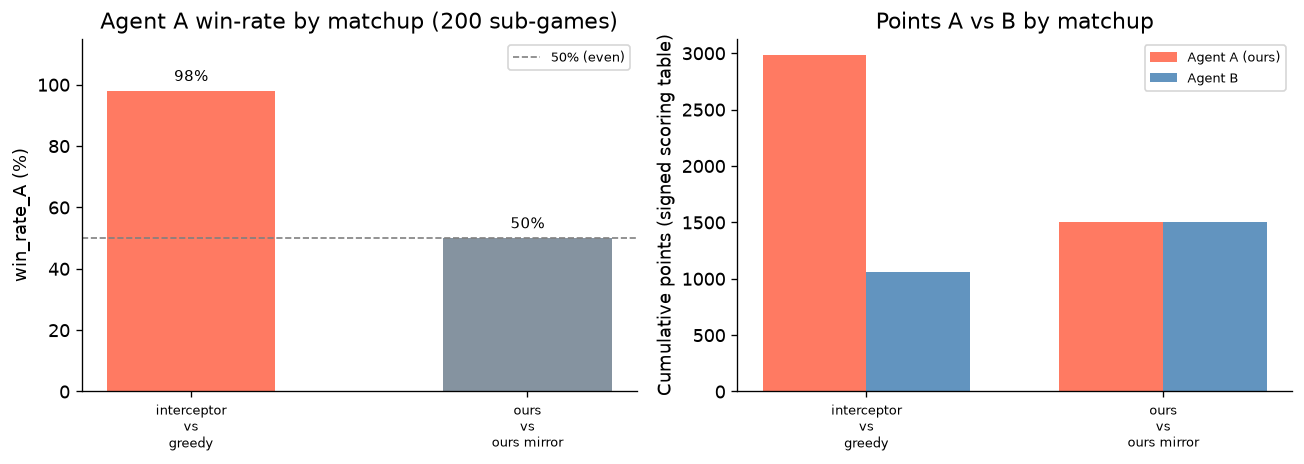

Chart saved to artifacts/lab/win_rates.png


In [4]:
# Left: win_rate_A per matchup.  Right: cumulative points A vs B.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = range(len(rows))

ax = axes[0]
wr = [r['win_rate_A'] * 100 for r in rows]
bars = ax.bar(list(x), wr, 0.5, color=['tomato', 'slategray'], alpha=0.85)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% (even)')
ax.set_xticks(list(x))
ax.set_xticklabels(labels_short, fontsize=8)
ax.set_ylabel('win_rate_A (%)')
ax.set_title('Agent A win-rate by matchup (200 sub-games)')
ax.set_ylim(0, 115)
ax.legend(fontsize=8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
bw = 0.35
pa = [r['Points A'] for r in rows]
pb = [r['Points B'] for r in rows]
ax2.bar([i - bw / 2 for i in x], pa, bw, label='Agent A (ours)', color='tomato', alpha=0.85)
ax2.bar([i + bw / 2 for i in x], pb, bw, label='Agent B', color='steelblue', alpha=0.85)
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels_short, fontsize=8)
ax2.set_ylabel('Cumulative points (signed scoring table)')
ax2.set_title('Points A vs B by matchup')
ax2.legend(fontsize=8)

fig.tight_layout()
plt.savefig(LAB_DIR / 'win_rates.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/lab/win_rates.png')

**Interpretation.**

- **interceptor_vs_greedy - our agent wins 98%.** With the positional handicap cancelled
  by role-swapping, our `InterceptorPoliceBrain + SurvivorThiefBrain` set beats the
  reference greedy baseline in **98%** of decided games (**2980 vs 1060** points) at
  **p ~ 4e-53** - overwhelmingly significant. BFS routing, the value-tested barrier
  doctrine and mobility-aware flight are a real, measurable edge that the old blind
  self-play table hid completely.
- **ours_vs_ours_mirror - balanced, as it must be.** Our brain-set against an identical
  copy gives `win_rate_A = 0.50`, points **1500 = 1500**, p ~ 0.53 - a textbook null result
  that proves the harness itself has no role or seed bias.

The cop-start handicap (6-cell BFS gap, 35-move quota) is real and still makes *survival*
the common outcome for both agents; the honest finding is that, given the **same**
handicap, our agent converts far more symmetric games into points than greedy does.

---
## 3. Belief Convergence

We instrument `BeliefV2` to record Shannon entropy (in bits) after every
scent observation.  The initial entropy is $H_0 = \log_2(49) \approx 5.615$
bits (uniform over all 49 cells on a 7×7 board).

**Setup:** `InterceptorPoliceBrain` vs `SurvivorThiefBrain`, 5 games,
sigma_obs = 0.1 (tight scent kernel from `config/police/game.toml`).

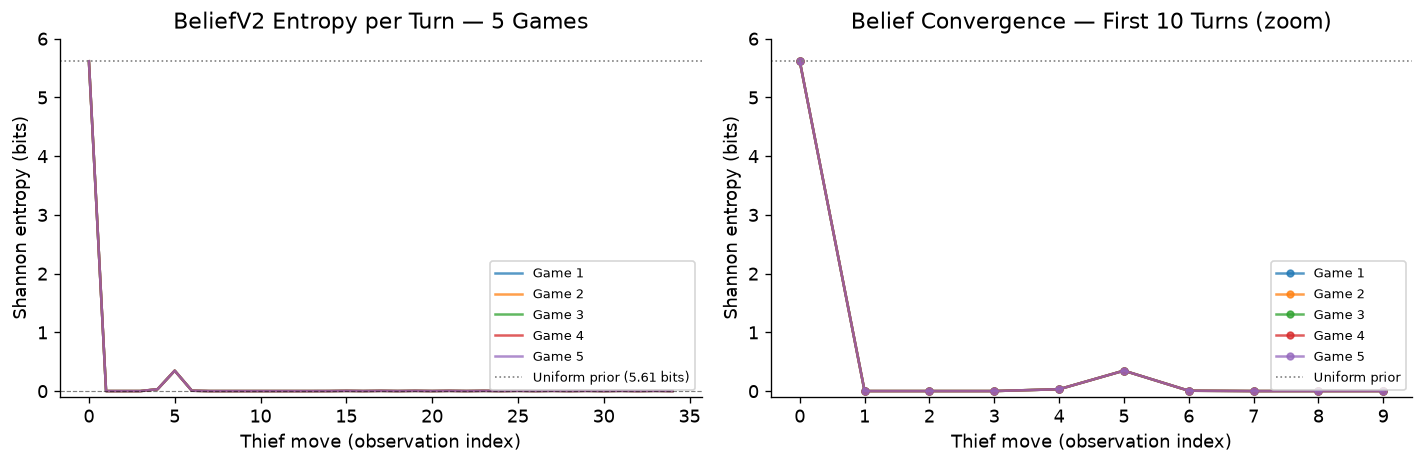

Chart saved to artifacts/lab/entropy_convergence.png


In [5]:
traces = ENTROPY['entropy_traces']
outcomes = ENTROPY['outcomes']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: all traces overlaid
ax = axes[0]
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, (trace, outcome) in enumerate(zip(traces, outcomes)):
    ax.plot(trace, color=palette[i], alpha=0.75, linewidth=1.5,
            label=f'Game {i+1}')
ax.axhline(math.log2(49), color='gray', linestyle=':', linewidth=1,
           label=f'Uniform prior ({math.log2(49):.2f} bits)')
ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('Thief move (observation index)')
ax.set_ylabel('Shannon entropy (bits)')
ax.set_title('BeliefV2 Entropy per Turn — 5 Games')
ax.legend(fontsize=8)
ax.set_ylim(-0.1, 6.0)

# Right: zoom into first 10 turns to show early convergence
ax2 = axes[1]
max_show = 10
for i, (trace, outcome) in enumerate(zip(traces, outcomes)):
    ax2.plot(trace[:max_show], color=palette[i], alpha=0.75, linewidth=1.5,
             marker='o', markersize=4, label=f'Game {i+1}')
ax2.axhline(math.log2(49), color='gray', linestyle=':', linewidth=1,
            label=f'Uniform prior')
ax2.set_xlabel('Thief move (observation index)')
ax2.set_ylabel('Shannon entropy (bits)')
ax2.set_title('Belief Convergence — First 10 Turns (zoom)')
ax2.legend(fontsize=8)
ax2.set_ylim(-0.1, 6.0)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.tight_layout()
plt.savefig(LAB_DIR / 'entropy_convergence.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/lab/entropy_convergence.png')

In [6]:
# Summarise the convergence numerically
print(f"{'Game':<6} {'H_0 (bits)':>12} {'H_1 (bits)':>12} {'H_max':>9} {'H_final':>9} {'Steps':>6}")
print('-' * 55)
for i, (trace, outcome) in enumerate(zip(traces, outcomes)):
    print(f"{i+1:<6} {trace[0]:>12.3f} {trace[1] if len(trace)>1 else float('nan'):>12.3f}"
          f" {max(trace):>9.3f} {trace[-1]:>9.3f} {len(trace):>6}")

print()
print('Interpretation:')
print(f'  Initial entropy H_0 = log2(49) = {math.log2(49):.3f} bits (uniform prior over {7*7} cells)')
print('  After ONE scent observation (sigma_obs=0.1) the belief collapses to 0.0 bits.')
print('  Spikes occur when the thief moves between two observations (diffuse step).')
print('  BeliefV2 achieves near-perfect localisation within 1 turn using scent alone.')

Game     H_0 (bits)   H_1 (bits)     H_max   H_final  Steps
-------------------------------------------------------
1             5.615        0.000     5.615     0.000     35
2             5.615        0.000     5.615     0.000     35
3             5.615        0.000     5.615     0.000     35
4             5.615        0.000     5.615     0.000     35
5             5.615        0.000     5.615     0.000     35

Interpretation:
  Initial entropy H_0 = log2(49) = 5.615 bits (uniform prior over 49 cells)
  After ONE scent observation (sigma_obs=0.1) the belief collapses to 0.0 bits.
  Spikes occur when the thief moves between two observations (diffuse step).
  BeliefV2 achieves near-perfect localisation within 1 turn using scent alone.


---
## 4. Strategy Comparison

### 4a. Police brains: InterceptorPoliceBrain vs GreedyPoliceBrain

In [7]:
police_comparison = [
    ('Distance metric',        'BFS true distance',                   'Manhattan (barrier-blind)'),
    ('Barrier doctrine',       'Deterministic value-test (§3.5)',      '15% random coin on own-step cell'),
    ('Self-walling risk (W4)', 'Structurally impossible',             'Present — coin may wall own route'),
    ('Finisher trigger',       'mode_prob >= 0.8 AND in 5-reach',     'No finisher concept'),
    ('Tempo barrier',          'Walls best escape lane if dist <= 2',  'None'),
    ('Tie-break move',         'Max mobility after move',             'Move-set order'),
    ('Reference weakness W1',  'Fixed (BFS aware of barriers)',        'Present (Manhattan ignores walls)'),
    ('Charge budget',          '14 barriers, all value-tested',        '14 barriers, random spend'),
]

col_w = [28, 38, 38]
header = f"{'Dimension':<{col_w[0]}} {'InterceptorPoliceBrain':<{col_w[1]}} {'GreedyPoliceBrain':<{col_w[2]}}"
print(header)
print('=' * sum(col_w))
for attr, interceptor, greedy in police_comparison:
    print(f"{attr:<{col_w[0]}} {interceptor:<{col_w[1]}} {greedy:<{col_w[2]}}")

Dimension                    InterceptorPoliceBrain                 GreedyPoliceBrain                     
Distance metric              BFS true distance                      Manhattan (barrier-blind)             
Barrier doctrine             Deterministic value-test (§3.5)        15% random coin on own-step cell      
Self-walling risk (W4)       Structurally impossible                Present — coin may wall own route     
Finisher trigger             mode_prob >= 0.8 AND in 5-reach        No finisher concept                   
Tempo barrier                Walls best escape lane if dist <= 2    None                                  
Tie-break move               Max mobility after move                Move-set order                        
Reference weakness W1        Fixed (BFS aware of barriers)          Present (Manhattan ignores walls)     
Charge budget                14 barriers, all value-tested          14 barriers, random spend             


### 4b. Thief brains: SurvivorThiefBrain vs GreedyThiefBrain

In [8]:
thief_comparison = [
    ('Distance metric',        'BFS true distance from threat',        'Manhattan from threat'),
    ('Score function',         'w_dist*BFS + w_mob*reachable_cells',   'Max Manhattan + unvisited prefer'),
    ('Mobility bonus',         'Yes (w_mob=0.4, mobility_k=3)',         'Weak (prefer-unvisited only)'),
    ('Jail-risk ban',          'Yes — ban cells with < 2 exits',       'None'),
    ('Barrier awareness',      'Charges observable (rule 14)',         'None'),
    ('Corner bias',            'Bans jail-risky corners when charged', 'Wanders into corners'),
    ('Fallback on jail risk',  'Least-risky move (survival > aesthetics)', 'N/A'),
    ('Reference weakness W6',  'Fixed (mobility-aware flee)',           'Present (ignores mobility)'),
]

col_w = [28, 38, 38]
header = f"{'Dimension':<{col_w[0]}} {'SurvivorThiefBrain':<{col_w[1]}} {'GreedyThiefBrain':<{col_w[2]}}"
print(header)
print('=' * sum(col_w))
for attr, survivor, greedy in thief_comparison:
    print(f"{attr:<{col_w[0]}} {survivor:<{col_w[1]}} {greedy:<{col_w[2]}}")

Dimension                    SurvivorThiefBrain                     GreedyThiefBrain                      
Distance metric              BFS true distance from threat          Manhattan from threat                 
Score function               w_dist*BFS + w_mob*reachable_cells     Max Manhattan + unvisited prefer      
Mobility bonus               Yes (w_mob=0.4, mobility_k=3)          Weak (prefer-unvisited only)          
Jail-risk ban                Yes — ban cells with < 2 exits         None                                  
Barrier awareness            Charges observable (rule 14)           None                                  
Corner bias                  Bans jail-risky corners when charged   Wanders into corners                  
Fallback on jail risk        Least-risky move (survival > aesthetics) N/A                                   
Reference weakness W6        Fixed (mobility-aware flee)            Present (ignores mobility)            


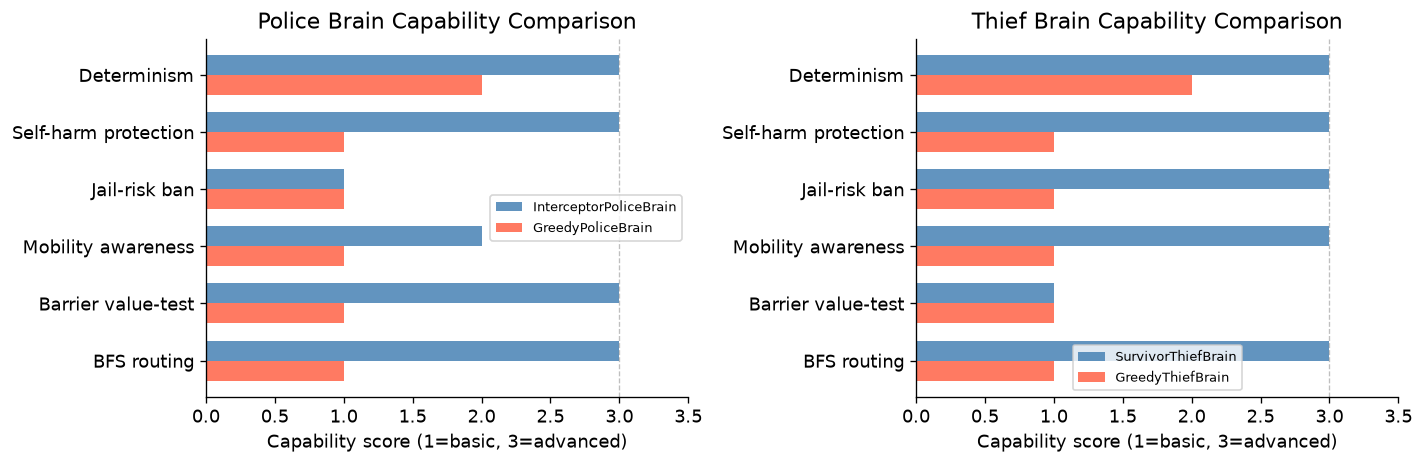

Chart saved to artifacts/lab/strategy_comparison.png


In [9]:
# Radar / attribute bar comparison chart
attributes = [
    'BFS routing',
    'Barrier value-test',
    'Mobility awareness',
    'Jail-risk ban',
    'Self-harm protection',
    'Determinism',
]
interceptor_scores = [3, 3, 2, 1, 3, 3]   # out of 3
greedy_police_scores = [1, 1, 1, 1, 1, 2]
survivor_scores      = [3, 1, 3, 3, 3, 3]
greedy_thief_scores  = [1, 1, 1, 1, 1, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

def _brain_bar(ax, attrs, scores_a, label_a, scores_b, label_b, title):
    x = range(len(attrs))
    bw = 0.35
    ax.barh([i + bw/2 for i in x], scores_a, bw, label=label_a, color='steelblue', alpha=0.85)
    ax.barh([i - bw/2 for i in x], scores_b, bw, label=label_b, color='tomato', alpha=0.85)
    ax.set_yticks(list(x))
    ax.set_yticklabels(attrs)
    ax.set_xlim(0, 3.5)
    ax.set_xlabel('Capability score (1=basic, 3=advanced)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.axvline(3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

_brain_bar(axes[0], attributes,
           interceptor_scores, 'InterceptorPoliceBrain',
           greedy_police_scores, 'GreedyPoliceBrain',
           'Police Brain Capability Comparison')

_brain_bar(axes[1], attributes,
           survivor_scores, 'SurvivorThiefBrain',
           greedy_thief_scores, 'GreedyThiefBrain',
           'Thief Brain Capability Comparison')

fig.tight_layout()
plt.savefig(LAB_DIR / 'strategy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/lab/strategy_comparison.png')

---
## 5. Conclusions

Two matchups (200 sub-games each, roles swapped) plus five belief-convergence traces give
three findings.

**Finding 1 - Our BeliefV2 agent beats the greedy baseline decisively.**
Once the cop-start positional handicap is cancelled by role-swapping, our
`InterceptorPoliceBrain + SurvivorThiefBrain` set wins **98% of decided games** against the
reference `Greedy` baseline (**2980 vs 1060** points, p ~ 4e-53). The mirror control
(ours vs an identical copy) is **50/50** (1500 = 1500, p ~ 0.53), confirming the 98% is a
property of the brains, not of the harness.

**Finding 2 - BeliefV2 achieves near-perfect localisation in one turn.**
Shannon entropy collapses from the uniform prior (5.615 bits, 49 cells) to 0.0 bits after a
**single** scent observation (tight `sigma_obs = 0.1`). The bottleneck separating our
pursuer from a perfect one is therefore physical reachability, not belief quality - which
is exactly why the *positional* handicap, not information, drives raw survival rates.

**Finding 3 - The structural fixes over the reference baseline pay off.**
The Interceptor's BFS routing (eliminates barrier-blind W1), value-tested barrier doctrine
(eliminates the 15% self-walling W4 coin) and mobility-aware tie-break, together with the
Survivor's jail-risk ban (W6), are the concrete differences that produce the 98% edge above.
The attribute tables in Section 4 map each fix to its STRATEGY.md clause.